In [1]:
import os; import jax.numpy as jnp
os.chdir("./src")  


from agent import Agent
from environment import H2ExportEnvironment


2026-02-02 15:16:08,094	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
agent = Agent(solve_date="2026-01-25", solve_id="12-56-56")
env = H2ExportEnvironment(solve_date="2026-01-25", solve_id="12-56-56")

I0000 00:00:1770045373.134361 42696419 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
I0000 00:00:1770045373.141264 42696610 service.cc:152] XLA service 0x357d38280 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770045373.141272 42696610 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1770045373.157995 42696610 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


True False [[-12239.3125]] {'constraint_values': Array([[-7.6323390e+00,  1.1593234e+02,  1.0493489e+05,  1.3141311e+05]],      dtype=float32)}
True False [[-11239.3125]] {'constraint_values': Array([[   336.50052,   -245.3005 , 113578.125  , 122769.875  ]], dtype=float32)}


<Figure size 3500x3500 with 0 Axes>

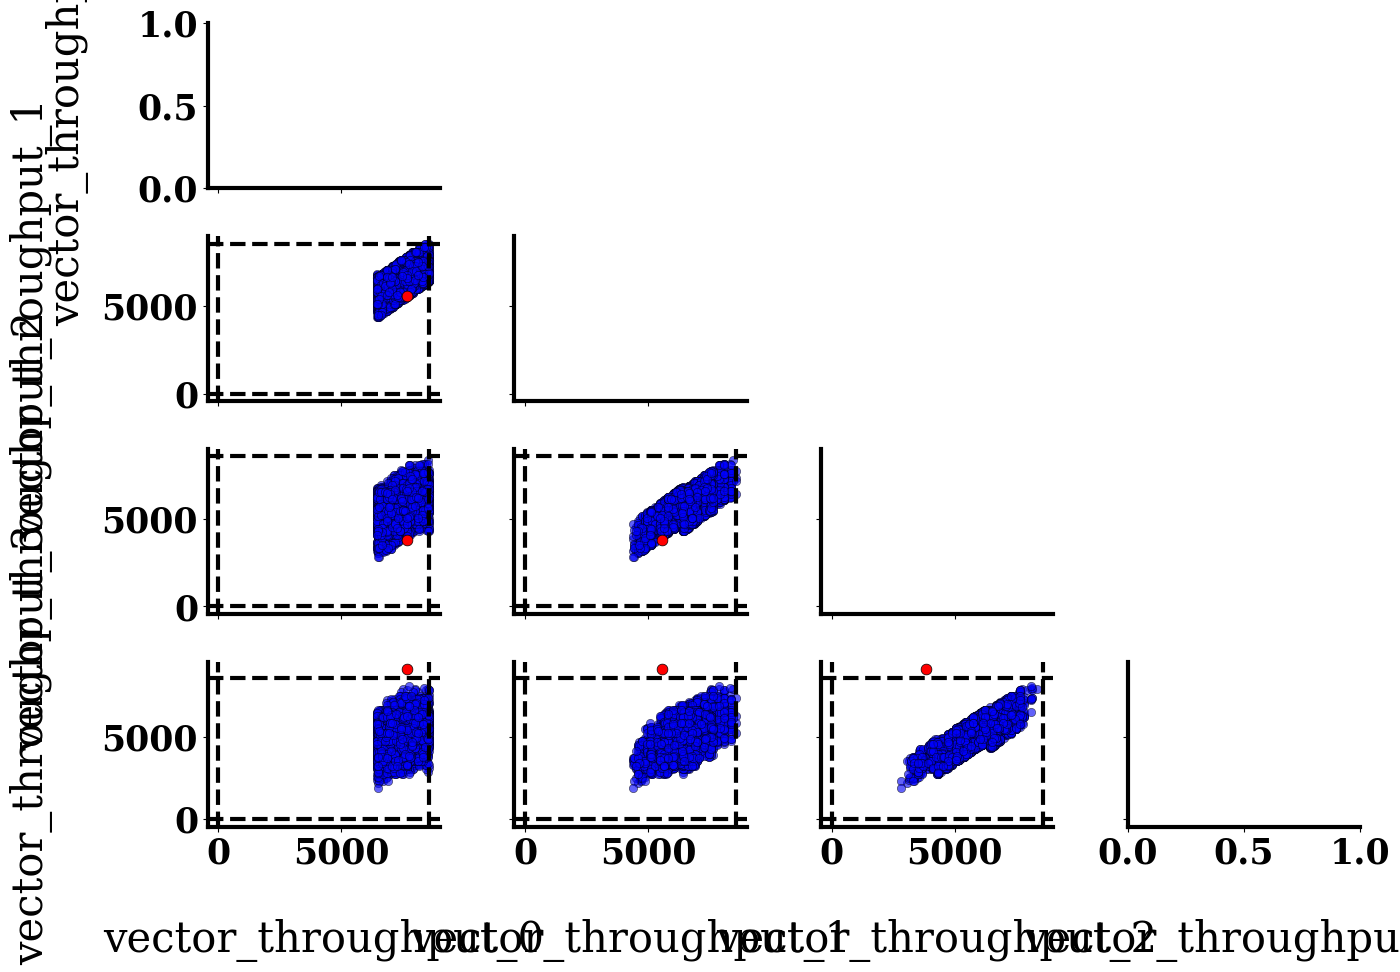

In [3]:
u = env.reset()

net_r = 0
count = 0
while True:
    v = agent.act(u)
    u, r, term, trunc, info = env.step(u, v)
    
    net_r += r
    if term or trunc:
        print(term, trunc, net_r, info)
    count += 1
    if count == 4:
        break
agent.add_policy_to_plot()

In [4]:
agent._actions

deque([(0, Array([[7669.0493]], dtype=float32)),
       (1, Array([[5570.263]], dtype=float32)),
       (2, Array([[3819.3752]], dtype=float32)),
       (3, Array([[9073.984]], dtype=float32))])